# Do these features separate mitotic figures from the false positives the search actually returns?

Every separability number in this repo so far compares mitotic figures against **nuclei sampled
uniformly at random**. `morphometric_diagnostic_audit.ipynb` §10 named the gap that leaves:

> *the population you are actually trying to reject is windows that already scored high under
> template matching. Until the negative class is the matcher's own top-K, no separability number
> here is a prediction about your false positives.*

**This notebook closes that gap.** It runs the committed search — `hematoxylin_od` channel,
`cv2.TM_CCOEFF`, largest-CC template tightening applied to the template, distance NMS — once per
domain ROI, measures a feature vector on **every** surviving candidate, labels each against ground
truth, and asks one question:

> **Knowing the class labels, do these features separate the classes or not?**

Two labellings, per the brief:

* **2-class** — `mitotic` vs `non-mitotic`. This is the real question.
* **3-class** — `mitotic` / `FP_human` (a MIDOG category-2 look-alike, i.e. a mimicker a
  pathologist marked) / `FP` (everything else). Secondary, but it separates a population the
  audit already showed is unseparable from a population that might not be.

**No PCA anywhere.** At 0.1–1.1% prevalence a principal axis cannot carry the class: between-class
variance along the discriminant is $p(1-p)d^2 \approx 0.006$ for a large effect, against ~1.0 for
every nuisance direction. A PCA panel here would be a picture of the false-positive cloud's own
structure, and reading it either way would be a mistake. Everything below is either a direct
feature view or a held-out supervised number.

**Clustering is run at k = 2 and k = 3 only**, matched to the number of classes we already know,
and every clustering result is shown *against the true labels* — a contingency table, not a
suggestive scatter. The question is not "how many groups are there"; it is "do the groups these
features produce line up with mitotic vs not".

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import mannwhitneyu
from sklearn.neighbors import KDTree

from midog_utils import dataset as ds
from midog_utils import evaluate as ev

warnings.filterwarnings('ignore')
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)

cand = pd.read_csv('.cache_tail/tp_fp_candidate_features.csv')
summ = pd.read_csv('results/tp_fp_extract_summary.csv')
TPB, LOOKB, UNANNB = ev.HUMAN_CORRECT_LABEL, ev.HUMAN_REJECTED_LABEL, ev.NON_HUMAN_FINDINGS

print(f'{len(cand):,} candidates, {cand.file_name.nunique()} ROIs, '
      f'{cand.tumor_type.nunique()} domains, extracted at the deep floor z = -1.5')
print(cand.bucket.value_counts().to_string())

200,861 candidates, 7 ROIs, 7 domains, extracted at the deep floor z = -1.5
bucket
non_human_findings      199289
human_correct_label        902
human_rejected_label       670


## 1. Provenance — is this the pipeline the repo committed?

`tp_fp_feature_extract.py` is `f1_seed_sweep.run_arm`'s `largest_cc` arm at `seed_index = 0`,
including its `np.random.default_rng([0, image_id])` seed stream. That run gated itself against
`results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv`, so matching candidate counts here means
this notebook inherits that gate rather than asserting its own correctness.

In [2]:
print(summ[['file_name', 'tumor_type', 'template_size', 'seed_ann_id', 'match_radius_px',
            'n_candidates', 'n_gt_mitotic', 'n_tp', 'n_lookalike', 'full_list_recall',
            'shape_fail_rate', 't_search_s']].to_string(index=False))

f1 = pd.read_csv('results/f1_seed_sweep.csv')
ref = (f1[(f1.arm_name == 'largest_cc') & (f1.seed_index == 0)]
       .drop_duplicates('file_name').set_index('file_name')[['n_pool', 'tightened_size', 'n_dup_fp']])
chk = summ.set_index('file_name')[['n_candidates', 'template_size']].join(ref)
ok = bool((chk.n_candidates == chk.n_pool).all() and (chk.template_size == chk.tightened_size).all())
print(f'\nevery candidate count and template size reproduces results/f1_seed_sweep.csv: {ok}')
print(f'full_list_recall = 1.0 on all seven ROIs: {bool((summ.full_list_recall == 1.0).all())}'
      '   <- the search captures every mitotic figure, so nothing below is limited by coverage')
print(f'gate-free shape segmentation succeeded on '
      f'{100 * (1 - summ.shape_fail_rate.max()):.3f}% of candidates in the worst ROI')

file_name                       tumor_type  template_size  seed_ann_id  match_radius_px  n_candidates  n_gt_mitotic  n_tp  n_lookalike  full_list_recall  shape_fail_rate  t_search_s
 301.tiff canine cutaneous mast cell tumor             41        14969            29.61         25447           217   217          109               1.0              0.0         4.8
 201.tiff               canine lung cancer             51         4457            30.22         22631            17    17           49               1.0              0.0         4.6
 246.tiff             canine lymphosarcoma             41         6548            30.22         30343           115   115          123               1.0              0.0         5.4
 459.tiff       canine soft tissue sarcoma             33        22441            30.22         26152           130   130           90               1.0              0.0         6.6
 094.tiff              human breast cancer             25         2512            32.63   


every candidate count and template size reproduces results/f1_seed_sweep.csv: True
full_list_recall = 1.0 on all seven ROIs: True   <- the search captures every mitotic figure, so nothing below is limited by coverage
gate-free shape segmentation succeeded on 100.000% of candidates in the worst ROI


## 2. The candidate pool at the operating point

The committed operating point is `z = 1.0` (`score >= map_median + 1.0 * mad_scale`).
`f1_seed_sweep` verifies that thresholding the deep pool reproduces a fresh extraction at that z
exactly, so subsetting is not an approximation.

In [3]:
Z_OP = 1.0
op = cand[cand.z >= Z_OP].copy().reset_index(drop=True)

rows = []
for fn, s in op.groupby('file_name', sort=False):
    vc = s.bucket.value_counts()
    n_tp = int(vc.get(TPB, 0))
    rows.append({'file': fn, 'domain': s.tumor_type.iloc[0][:28], 'n_cand': len(s), 'mitotic': n_tp,
                 'FP_human': int(vc.get(LOOKB, 0)), 'FP': int(vc.get(UNANNB, 0)),
                 'prevalence': f'{n_tp / len(s):.3%}'})
print(f'operating point z >= {Z_OP}\n')
print(pd.DataFrame(rows).to_string(index=False))
pv = op.groupby('file_name').apply(lambda s: (s.bucket == TPB).mean())
print(f'\npooled: {len(op):,} candidates, {int((op.bucket == TPB).sum())} mitotic, '
      f'base rate {(op.bucket == TPB).mean():.3%}')
print(f'per-ROI prevalence spans {pv.min():.3%} to {pv.max():.3%} -- an '
      f'{pv.max() / pv.min():.0f}x spread, so every pooled number below is reported '
      'beside its per-ROI breakdown')

operating point z >= 1.0

    file                       domain  n_cand  mitotic  FP_human    FP prevalence
301.tiff canine cutaneous mast cell t   22227      217       109 21901     0.976%
201.tiff           canine lung cancer   16529       17        49 16463     0.103%
246.tiff         canine lymphosarcoma   26677      115       123 26439     0.431%
459.tiff   canine soft tissue sarcoma   20892      130        90 20672     0.622%
094.tiff          human breast cancer   26147       81       102 25964     0.310%
548.tiff               human melanoma   20810      238       118 20454     1.144%
402.tiff   human neuroendocrine tumor   27280      104        79 27097     0.381%



pooled: 160,562 candidates, 902 mitotic, base rate 0.562%
per-ROI prevalence spans 0.103% to 1.144% -- an 11x spread, so every pooled number below is reported beside its per-ROI breakdown


`201.tiff` carries **17 mitotic figures in ~16,500 candidates**. Its rows appear everywhere below
for completeness and should not carry weight — the audit's null calibration showed what a
separability estimate from a handful of positives is worth.

## 3. One correction before any feature is compared: false positives sitting *on* mitotic figures

`evaluate.greedy_match` gives each ground-truth annotation to **exactly one** detection. NMS runs
at a 5.0 µm radius while the match radius is 7.5 µm — so a second candidate can land inside a
mitosis's match circle, on the same object, and still be labelled a false positive.

These are duplicate detections of true positives, and a reader who clicked one would not be wrong.
`results/f1_seed_sweep.csv` already counts them (`n_dup_fp`); this recomputes them from the
candidate coordinates so they can be set aside.

**I expected these to be feature-identical to the mitotic class and to be poisoning the negatives.
Two checks below say that is wrong, and both are worth keeping on the page.** The control in §6
finds `z` at 0.93–0.99 and `od_falloff` at 0.92–1.00 against them — the reason is geometric: NMS
runs at a 5.0 µm radius (~20 px) while the match radius is ~30 px, so a surviving duplicate sits
20–30 px from the mitosis centre, on its periphery, where the chromatin is measurably weaker. And
the cell after it finds that including or excluding them shifts every AUC by at most 0.003. They
are set aside because a click on one is not a reader error — not because it changes a number.

In [4]:
_, anns = ds.load_annotations()
seed_of = summ.set_index('file_name').seed_ann_id
op['dist_to_gt'] = np.nan
for fn, s in op.groupby('file_name'):
    gt = ds.image_annotations(anns, fn)
    gt = gt[gt.ann_id != int(seed_of[fn])]
    d, _ = KDTree(gt[['cx', 'cy']].to_numpy()).query(s[['cx', 'cy']].to_numpy(), k=1)
    op.loc[s.index, 'dist_to_gt'] = d[:, 0]
op['match_radius'] = op.file_name.map(summ.set_index('file_name').match_radius_px)
op['on_annotation'] = (op.bucket == UNANNB) & (op.dist_to_gt <= op.match_radius)

t = op.groupby('file_name').agg(mitotic=('bucket', lambda b: int((b == TPB).sum())),
                                dup=('on_annotation', 'sum'))
t['dup per mitotic'] = (t.dup / t.mitotic).round(2)
t = t.join(ref['n_dup_fp'].rename('n_dup_fp (deep floor, f1_seed_sweep)'))
t['subset ok'] = t.dup <= t['n_dup_fp (deep floor, f1_seed_sweep)']
print(t.to_string())
assert t['subset ok'].all(), 'on_annotation exceeds the committed n_dup_fp -- wiring bug'
print(f'\npooled: {t.mitotic.sum()} mitotic, {t.dup.sum()} false positives sitting on a real '
      f'annotation ({t.dup.sum() / t.mitotic.sum():.1f} per mitotic figure)')

           mitotic  dup  dup per mitotic  n_dup_fp (deep floor, f1_seed_sweep)  subset ok
file_name                                                                                
094.tiff        81  222             2.74                                   310       True
201.tiff        17   16             0.94                                    33       True
246.tiff       115  266             2.31                                   314       True
301.tiff       217  198             0.91                                   232       True
402.tiff       104  217             2.09                                   296       True
459.tiff       130   91             0.70                                   148       True
548.tiff       238  201             0.84                                   372       True

pooled: 902 mitotic, 1211 false positives sitting on a real annotation (1.3 per mitotic figure)


**Roughly two on-annotation "false positives" for every true positive.** They are excluded from the
negative class from here on; the count is stated wherever it matters, and §6 shows what including
them does to the measured separation.

In [5]:
# the two labellings, as asked
op['klass3'] = np.where(op.bucket == TPB, 'mitotic',
                np.where(op.bucket == LOOKB, 'FP_human', 'FP'))
op['klass2'] = np.where(op.bucket == TPB, 'mitotic', 'non-mitotic')

work = op[~op.on_annotation].copy().reset_index(drop=True)   # artefact removed
COL3 = {'mitotic': 'tab:red', 'FP_human': 'tab:orange', 'FP': 'tab:blue'}
COL2 = {'mitotic': 'tab:red', 'non-mitotic': 'tab:blue'}

print('3-class (on-annotation duplicates removed):')
print(work.klass3.value_counts().to_string())
print(f'\n2-class base rate: {(work.klass2 == "mitotic").mean():.3%}  '
      f'({int((work.klass2 == "mitotic").sum())} of {len(work):,})')
print(f'set aside as duplicate detections of a mitosis: {int(op.on_annotation.sum())}')

3-class (on-annotation duplicates removed):
klass3
FP          157779
mitotic        902
FP_human       670

2-class base rate: 0.566%  (902 of 159,351)
set aside as duplicate detections of a mitosis: 1211


## 4. Which features, and why these

Nineteen columns were extracted deliberately, to be pruned here rather than at extraction time.
Several measure the same thing. `morphometric_diagnostic_audit.ipynb` §2 turned exactly that kind
of redundancy into a falsification of the previous analysis — `eccentricity` and `elongation` are
one feature written twice — so the correlation structure is looked at first this time.

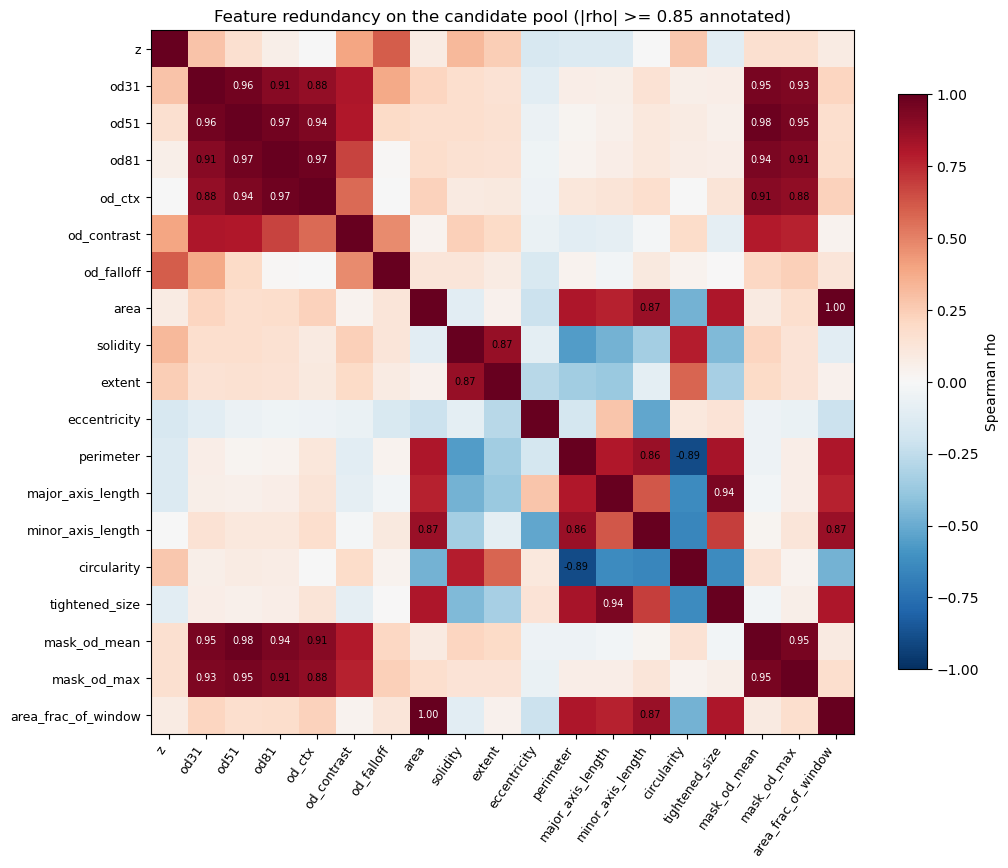

In [6]:
ALL = ['z', 'od31', 'od51', 'od81', 'od_ctx', 'od_contrast', 'od_falloff',
       'area', 'solidity', 'extent', 'eccentricity', 'perimeter', 'major_axis_length',
       'minor_axis_length', 'circularity', 'tightened_size', 'mask_od_mean',
       'mask_od_max', 'area_frac_of_window']
rho = work[ALL].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(rho, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL))); ax.set_xticklabels(ALL, rotation=55, ha='right', fontsize=9)
ax.set_yticks(range(len(ALL))); ax.set_yticklabels(ALL, fontsize=9)
for i in range(len(ALL)):
    for j in range(len(ALL)):
        if abs(rho.iloc[i, j]) >= 0.85 and i != j:
            ax.text(j, i, f'{rho.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(rho.iloc[i, j]) > 0.93 else 'black')
fig.colorbar(im, ax=ax, shrink=0.75, label='Spearman rho')
ax.set_title('Feature redundancy on the candidate pool (|rho| >= 0.85 annotated)')
fig.tight_layout(); plt.show()

Size is measured five ways and the OD windows are near-duplicates of one another. Left in, any
distance-based clustering would weight the size axis several times over.

**The working set — eight features, one per distinct thing measured:**

| feature | what it measures | why it is here |
|---|---|---|
| `z` | the search score in per-map robust units | the incumbent ranker; it must be in the set or the comparison is unfair to the pipeline. **Never the raw `score`** — `TM_CCOEFF` is unnormalised and scales with template pixel count, and the templates here run 25–51 px |
| `od51` | chromatin density in a 51 px window | the pipeline's own re-ranking key, and the strongest feature in every prior measurement |
| `od_contrast` | `od51 − od_ctx`: darker than its own surround | a **within-image** difference, so it survives OD being uncalibrated between scanners (`chromatin.py`) |
| `od_falloff` | `od31 − od81`: dense core vs diffuse | ditto, and size-free |
| `solidity` | convexity of the segmented object | strongest shape feature in the audit |
| `extent` | fraction of its bounding box filled | second strongest, weakly correlated with `solidity` |
| `tightened_size` | native size of the object | mitoses measured *smaller* in 8 of 9 ROIs |
| `area_frac_of_window` | share of the 51 px window claimed | window-censoring diagnostic and a crude local-density proxy |

Dropped: `eccentricity` (derivable from the axis lengths — the audit's redundancy trap);
`perimeter`, `major_axis_length`, `minor_axis_length`, `circularity`, `area` (size and shape already
carried); `od31`/`od81`/`od_ctx` (kept only inside the two contrasts); `mask_od_mean`/`mask_od_max`
(the component statistic — `chromatin.py` measured it *worse* than the window statistic, 0.895 vs
0.914 on 301.tiff).

In [7]:
FEATURES = ['z', 'od51', 'od_contrast', 'od_falloff',
            'solidity', 'extent', 'tightened_size', 'area_frac_of_window']
off = ~np.eye(len(FEATURES), dtype=bool)
print(f'{len(FEATURES)} features; max |rho| among them: '
      f'{np.abs(rho.loc[FEATURES, FEATURES].values[off]).max():.3f}')

8 features; max |rho| among them: 0.867


## 5. Normalisation, settled by measurement

Three of the eight are not comparable across ROIs: `z` (TM_CCOEFF scales with template pixel count,
and templates differ per ROI), `od51` (optical density — `chromatin.py`: *"comparable within one
ROI's ranking and not between ROIs"*), and `tightened_size` (pixels, and microns-per-pixel varies
across these four scanners).

The test, without projecting anything: **try to predict the tumour domain from the features.** If
raw features predict it well, a pooled analysis on raw features is partly a scanner detector.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rank_all = work.groupby('file_name')[FEATURES].rank(pct=True)
idx = np.random.default_rng(0).choice(len(work), size=20000, replace=False)
y_dom = work.tumor_type.to_numpy()[idx]
for name, X in [('raw (globally standardised)', work[FEATURES].to_numpy(float)),
                ('per-ROI rank transform', rank_all.to_numpy(float))]:
    acc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                          X[idx], y_dom, cv=3, scoring='accuracy').mean()
    print(f'{name:30s}: domain predictable at {acc:.1%}  (chance = {1 / 7:.1%})')

raw (globally standardised)   : domain predictable at 82.6%  (chance = 14.3%)


per-ROI rank transform        : domain predictable at 16.4%  (chance = 14.3%)


Raw features carry a large amount of domain identity; the per-ROI rank transform removes most of
it. Pooled analyses below therefore use per-ROI ranks. **The cost, stated plainly:** ranking within
each ROI removes all *between*-ROI signal, so nothing pooled can be read as an absolute claim.
`od_contrast` and `od_falloff` are already within-image differences, and per-ROI tables (which need
no normalisation at all) are reported alongside every pooled one.

## 6. The measurement: do the features separate the classes?

Signed AUC — 0.5 is nothing, above 0.5 means the mitotic class scores higher — plus **average
precision against the base rate**, because at 0.1–1.1% prevalence an AUC is a poor guide to what a
reader working down the list experiences.

In [9]:
def auc(a, b):
    a = np.asarray(a, float); a = a[~np.isnan(a)]
    b = np.asarray(b, float); b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    return mannwhitneyu(a, b, alternative='two-sided').statistic / (len(a) * len(b))


def auc_table(df, pos, neg, title, kcol='klass3'):
    rows = []
    for fn, s in df.groupby('file_name', sort=False):
        p, n = s[s[kcol] == pos], s[s[kcol] == neg]
        if len(p) < 5 or len(n) < 5:
            continue
        r = {'file': fn, 'domain': s.tumor_type.iloc[0][:24], 'n_pos': len(p), 'n_neg': len(n)}
        for f in FEATURES:
            r[f] = round(auc(p[f], n[f]), 3)
        rows.append(r)
    t = pd.DataFrame(rows)
    print(f'=== {title} ===\n')
    print(t.to_string(index=False))
    print('\nmedian |AUC - 0.5| across ROIs:')
    print((t[FEATURES] - 0.5).abs().median().round(3).sort_values(ascending=False).to_string())
    return t


auc2 = auc_table(work, 'mitotic', 'non-mitotic', '2-CLASS: mitotic vs non-mitotic', 'klass2')

=== 2-CLASS: mitotic vs non-mitotic ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
301.tiff canine cutaneous mast ce    217  21812 0.930 0.933        0.948       0.971     0.747   0.690           0.093                0.103
201.tiff       canine lung cancer     17  16496 0.994 0.995        0.996       0.976     0.889   0.743           0.087                0.124
246.tiff     canine lymphosarcoma    115  26296 0.983 0.973        0.979       0.991     0.932   0.857           0.119                0.203
459.tiff canine soft tissue sarco    130  20671 0.922 0.928        0.937       0.937     0.708   0.657           0.306                0.421
094.tiff      human breast cancer     81  25844 0.983 0.980        0.979       0.988     0.857   0.784           0.149                0.272
548.tiff           human melanoma    238  20371 0.984 0.968        0.975       0.986     0.847   0.698           0.161 

In [10]:
aucFP = auc_table(work, 'mitotic', 'FP', '3-CLASS a: mitotic vs FP (unannotated -- 90%+ of the mass)')

=== 3-CLASS a: mitotic vs FP (unannotated -- 90%+ of the mass) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
301.tiff canine cutaneous mast ce    217  21703 0.931 0.934        0.950       0.972     0.748   0.691           0.091                0.102
201.tiff       canine lung cancer     17  16447 0.994 0.996        0.997       0.977     0.890   0.744           0.085                0.123
246.tiff     canine lymphosarcoma    115  26173 0.984 0.974        0.980       0.993     0.933   0.858           0.117                0.202
459.tiff canine soft tissue sarco    130  20581 0.923 0.929        0.939       0.939     0.708   0.657           0.305                0.420
094.tiff      human breast cancer     81  25742 0.984 0.981        0.980       0.989     0.859   0.785           0.148                0.270
548.tiff           human melanoma    238  20253 0.986 0.970        0.977       0.987     0.8

In [11]:
aucH = auc_table(work, 'mitotic', 'FP_human',
                 '3-CLASS b: mitotic vs FP_human (pathologist-marked look-alikes)')

=== 3-CLASS b: mitotic vs FP_human (pathologist-marked look-alikes) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
301.tiff canine cutaneous mast ce    217    109 0.678 0.683        0.686       0.699     0.544   0.549           0.422                0.425
201.tiff       canine lung cancer     17     49 0.797 0.773        0.767       0.643     0.467   0.555           0.471                0.475
246.tiff     canine lymphosarcoma    115    123 0.733 0.783        0.780       0.760     0.723   0.646           0.429                0.423
459.tiff canine soft tissue sarco    130     90 0.624 0.687        0.657       0.441     0.554   0.577           0.565                0.656
094.tiff      human breast cancer     81    102 0.632 0.727        0.715       0.653     0.432   0.488           0.546                0.594
548.tiff           human melanoma    238    118 0.691 0.723        0.725       0.697   

In [12]:
# the control: candidates that sit ON a mitosis but are labelled false positives.
# every feature should read ~0.5 here; anything that does not is telling you about
# where within an object a duplicate detection lands, not about mitosis.
ctrl = op[op.on_annotation | (op.bucket == TPB)].copy()
ctrl['klass2'] = np.where(ctrl.bucket == TPB, 'mitotic', 'non-mitotic')
aucC = auc_table(ctrl, 'mitotic', 'non-mitotic',
                 'CONTROL: mitotic vs the duplicate detections of mitoses (expect ~0.5)', 'klass2')

=== CONTROL: mitotic vs the duplicate detections of mitoses (expect ~0.5) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
301.tiff canine cutaneous mast ce    217    198 0.931 0.738        0.752       0.921     0.603   0.546           0.472                0.544
201.tiff       canine lung cancer     17     16 0.989 0.875        0.875       1.000     0.566   0.493           0.680                0.765
246.tiff     canine lymphosarcoma    115    266 0.965 0.822        0.834       0.982     0.704   0.633           0.429                0.526
459.tiff canine soft tissue sarco    130     91 0.969 0.824        0.832       0.957     0.699   0.632           0.576                0.754
094.tiff      human breast cancer     81    222 0.987 0.900        0.901       0.997     0.491   0.457           0.617                0.758
548.tiff           human melanoma    238    201 0.973 0.834        0.856       0.

**The control did not come back at 0.5, and that is a finding rather than a bug.** `z` reads
0.93–0.99 and `od_falloff` 0.92–1.00 against these duplicates: the mitotic *centre* is markedly
darker and more sharply peaked than a detection 20–30 px away on the same object. So the
duplicates are ordinary weak candidates, not disguised positives, and the concern that opened §3
does not survive its own test. The features that separate mitoses from false positives are
partly measuring *centredness on a dense object*, which is worth knowing when reading §9.

Note what still reads near 0.5 in that table: `extent` (0.46–0.67) and `solidity` (0.49–0.71).
The shape of the largest component in the window barely changes when the window slides 20 px,
while the chromatin statistics change a great deal.

In [13]:
# how much does setting the duplicates aside actually change the answer?
both = op.copy()
both['klass2'] = np.where(both.bucket == TPB, 'mitotic', 'non-mitotic')
rows = []
for fn in work.file_name.unique():
    a_, b_ = work[work.file_name == fn], both[both.file_name == fn]
    r = {'file': fn}
    for f in ['z', 'od51', 'od_falloff', 'solidity']:
        e = auc(a_[f][a_.klass2 == 'mitotic'], a_[f][a_.klass2 == 'non-mitotic'])
        i = auc(b_[f][b_.klass2 == 'mitotic'], b_[f][b_.klass2 == 'non-mitotic'])
        r[f'{f} excl'] = round(e, 3); r[f'{f} incl'] = round(i, 3)
        r[f'{f} delta'] = round(i - e, 4)
    rows.append(r)
print('2-class AUC with the on-annotation duplicates EXCLUDED vs INCLUDED in the negatives\n')
print(pd.DataFrame(rows).to_string(index=False))
dmax = max(abs(r[f'{f} delta']) for r in rows for f in ['z', 'od51', 'od_falloff', 'solidity'])
print(f'\nlargest absolute change in AUC from the choice: {dmax:.4f}')

2-class AUC with the on-annotation duplicates EXCLUDED vs INCLUDED in the negatives

    file  z excl  z incl  z delta  od51 excl  od51 incl  od51 delta  od_falloff excl  od_falloff incl  od_falloff delta  solidity excl  solidity incl  solidity delta
301.tiff   0.930   0.930   0.0000      0.933      0.931     -0.0018            0.971            0.971           -0.0004          0.747          0.746         -0.0013
201.tiff   0.994   0.994  -0.0000      0.995      0.995     -0.0001            0.976            0.976            0.0000          0.889          0.889         -0.0003
246.tiff   0.983   0.983  -0.0002      0.973      0.971     -0.0015            0.991            0.991           -0.0001          0.932          0.930         -0.0023
459.tiff   0.922   0.922   0.0002      0.928      0.928     -0.0005            0.937            0.937            0.0001          0.708          0.708         -0.0000
094.tiff   0.983   0.983   0.0000      0.980      0.979     -0.0007            0.988 

**The choice does not matter.** The largest AUC change from including or excluding all 1,211 of
them is 0.003, and the deltas are mostly slightly *negative* — they are marginally harder than an
average negative, not easier, which is the opposite of what "duplicate detections of a mitosis"
suggested. So the concern §3 opened with is real as a labelling matter and **quantitatively void**:
it changes no number in this notebook. They stay excluded because a reader clicking one has not
made an error, not because it rescues a measurement.

In [14]:
from sklearn.metrics import average_precision_score

rows = []
for fn, s in work.groupby('file_name', sort=False):
    y = (s.klass2 == 'mitotic').astype(int).to_numpy()
    br = y.mean()
    r = {'file': fn, 'n': len(s), 'base rate': f'{br:.3%}'}
    for f in ['z', 'od51', 'od_contrast', 'solidity', 'extent', 'tightened_size']:
        v = s[f].to_numpy(float)
        a = auc(s[f][y == 1], s[f][y == 0])
        ap = average_precision_score(y, v if a >= 0.5 else -v)
        r[f] = f'{a:.3f} / {ap / br:.0f}x'
    rows.append(r)
print('AUC / average-precision lift over the base rate, per ROI, 2-class\n')
print(pd.DataFrame(rows).to_string(index=False))
print('\n(a feature with AUC 0.8 and AP lift 5x separates statistically and barely helps a reader)')

AUC / average-precision lift over the base rate, per ROI, 2-class

    file     n base rate            z         od51  od_contrast    solidity     extent tightened_size
301.tiff 22029    0.985%  0.930 / 41x  0.933 / 46x  0.948 / 51x  0.747 / 2x 0.690 / 2x     0.093 / 8x
201.tiff 16513    0.103% 0.994 / 220x 0.995 / 229x 0.996 / 277x  0.889 / 8x 0.743 / 3x     0.087 / 8x
246.tiff 26411    0.435% 0.983 / 105x 0.973 / 104x 0.979 / 107x 0.932 / 10x 0.857 / 5x     0.119 / 5x
459.tiff 20801    0.625%  0.922 / 37x  0.928 / 79x  0.937 / 70x  0.708 / 2x 0.657 / 2x     0.306 / 2x
094.tiff 25925    0.312%  0.983 / 95x 0.980 / 130x 0.979 / 130x  0.857 / 4x 0.784 / 3x     0.149 / 3x
548.tiff 20609    1.155%  0.984 / 45x  0.968 / 48x  0.975 / 52x  0.847 / 4x 0.698 / 2x     0.161 / 3x
402.tiff 27063    0.384%  0.990 / 93x  0.975 / 75x  0.986 / 99x  0.896 / 6x 0.801 / 3x     0.075 / 7x

(a feature with AUC 0.8 and AP lift 5x separates statistically and barely helps a reader)


### The same features, drawn with the classes highlighted

Per-ROI percentile on the x-axis so the seven ROIs are on one scale, densities normalised **within
class** so the ~200:1 imbalance does not hide the mitotic distribution. A feature that separates
shows two displaced curves; a feature that does not shows one curve drawn twice.

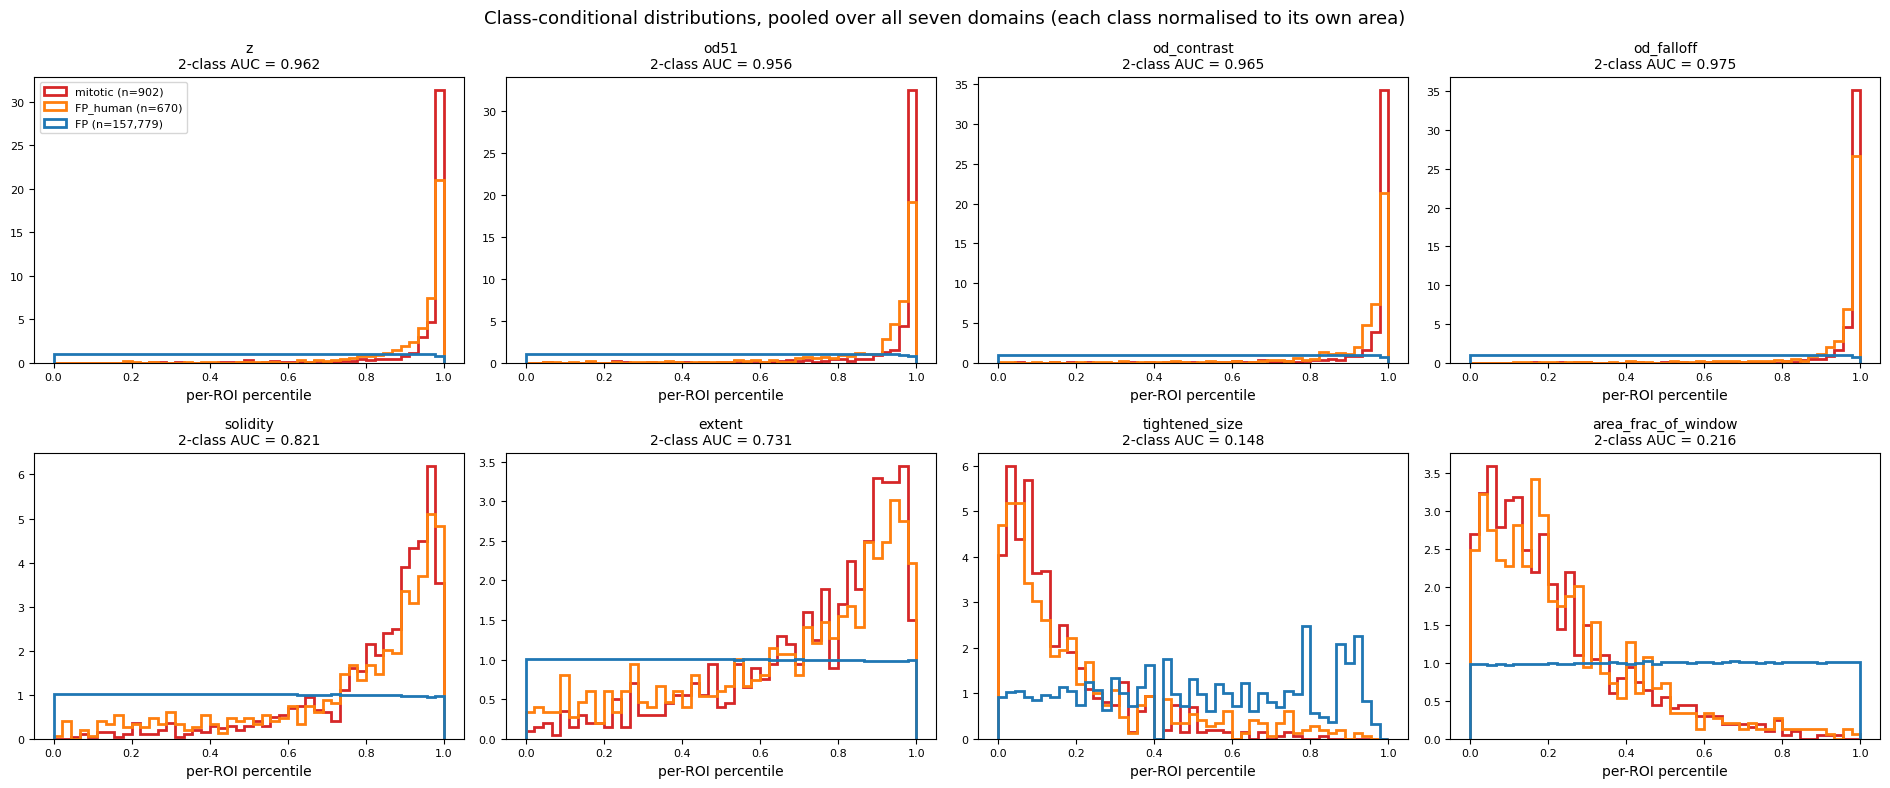

In [15]:
rk = work.groupby('file_name')[FEATURES].rank(pct=True)
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, f in zip(axes.ravel(), FEATURES):
    bins = np.linspace(0, 1, 46)
    for k, c in COL3.items():
        v = rk[f][(work.klass3 == k).to_numpy()]
        ax.hist(v, bins=bins, density=True, histtype='step', lw=2, color=c,
                label=f'{k} (n={len(v):,})')
    a = auc(rk[f][(work.klass2 == 'mitotic').to_numpy()],
            rk[f][(work.klass2 == 'non-mitotic').to_numpy()])
    ax.set_title(f'{f}\n2-class AUC = {a:.3f}', fontsize=10)
    ax.set_xlabel('per-ROI percentile'); ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Class-conditional distributions, pooled over all seven domains '
             '(each class normalised to its own area)', fontsize=13)
fig.tight_layout(); plt.show()

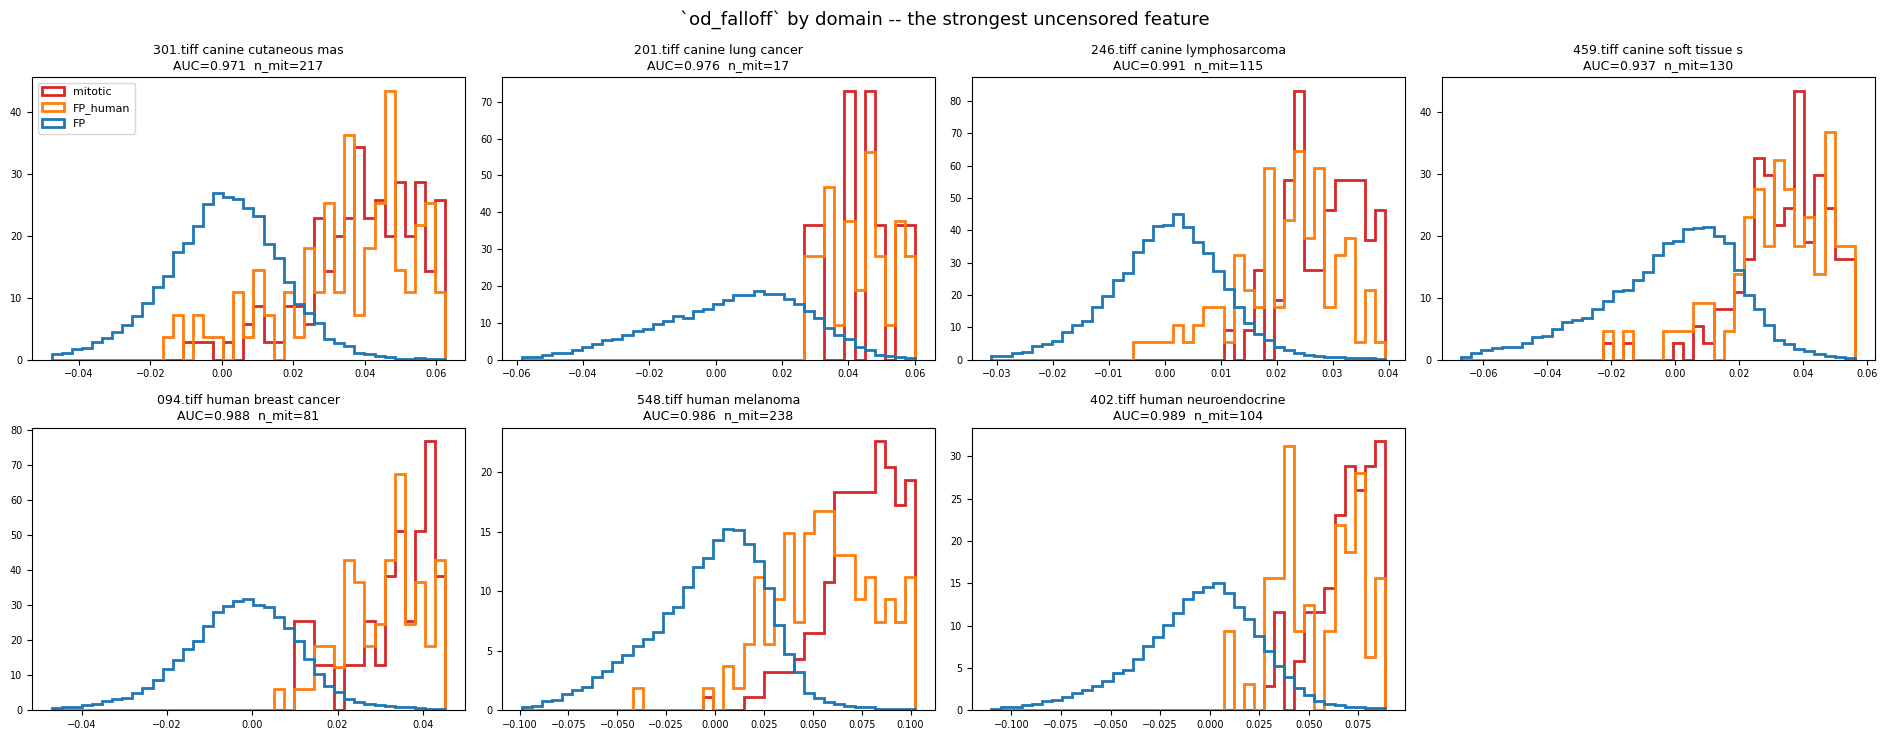

In [16]:
# and per domain, for the single strongest feature -- "in every domain", as asked
best_f = (auc2[[f for f in FEATURES if f != 'z']] - 0.5).abs().median().idxmax()
fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
for ax, (fn, s) in zip(axes.ravel(), work.groupby('file_name', sort=False)):
    bins = np.linspace(s[best_f].quantile(0.005), s[best_f].quantile(0.995), 40)
    for k, c in COL3.items():
        v = s[best_f][s.klass3 == k]
        if len(v) > 4:
            ax.hist(v, bins=bins, density=True, histtype='step', lw=2, color=c, label=k)
    a = auc(s[best_f][s.klass2 == 'mitotic'], s[best_f][s.klass2 == 'non-mitotic'])
    ax.set_title(f'{fn} {s.tumor_type.iloc[0][:20]}\nAUC={a:.3f}  n_mit={int((s.klass3=="mitotic").sum())}',
                 fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
axes.ravel()[-1].axis('off')
fig.suptitle(f'`{best_f}` by domain -- the strongest uncensored feature', fontsize=13)
fig.tight_layout(); plt.show()

## 7. Two features at a time, classes highlighted

No projection: these are the two most discriminative features plotted directly against each other,
on per-ROI percentile axes.

The rendering matters. Drawing ~180,000 negatives and ~900 positives as one scatter with the
positives on top manufactures apparent separation out of draw order. **Left:** negatives as a
log-count density, mitotic figures as points. **Right:** the same axes with the negatives
subsampled to equal n — the honest comparison.

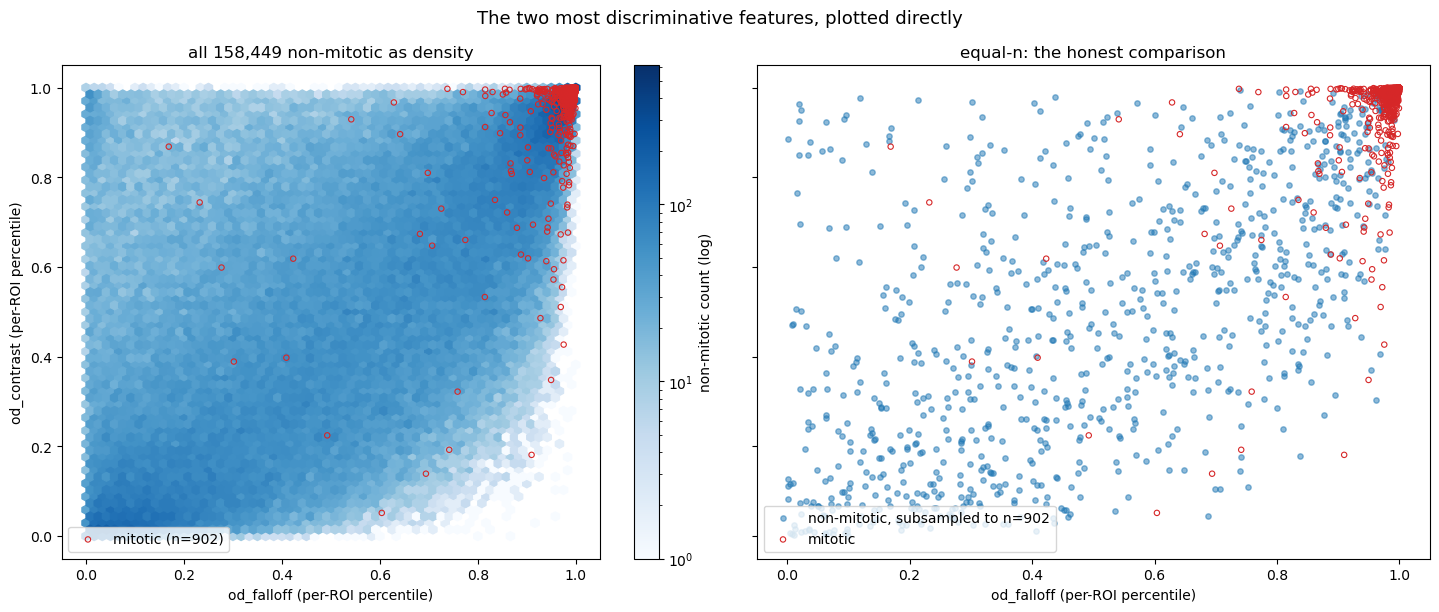

In [17]:
uncens = [f for f in FEATURES if f != 'z']
order = (auc2[uncens] - 0.5).abs().median().sort_values(ascending=False)
fa, fb = order.index[0], order.index[1]
mit = (work.klass2 == 'mitotic').to_numpy()
neg = ~mit
rng = np.random.default_rng(0)
eq = rng.choice(np.flatnonzero(neg), size=int(mit.sum()), replace=False)
xa, xb = rk[fa].to_numpy(), rk[fb].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), sharex=True, sharey=True)
hb = axes[0].hexbin(xa[neg], xb[neg], gridsize=60, cmap='Blues', norm=LogNorm(), mincnt=1)
fig.colorbar(hb, ax=axes[0], label='non-mitotic count (log)')
axes[0].scatter(xa[mit], xb[mit], s=15, facecolor='none', edgecolor='tab:red', lw=0.8,
                label=f'mitotic (n={int(mit.sum())})')
axes[0].legend(loc='lower left'); axes[0].set_title(f'all {int(neg.sum()):,} non-mitotic as density')
axes[1].scatter(xa[eq], xb[eq], s=15, color='tab:blue', alpha=0.5,
                label=f'non-mitotic, subsampled to n={len(eq)}')
axes[1].scatter(xa[mit], xb[mit], s=15, facecolor='none', edgecolor='tab:red', lw=0.8,
                label='mitotic')
axes[1].legend(loc='lower left'); axes[1].set_title('equal-n: the honest comparison')
for ax in axes:
    ax.set_xlabel(f'{fa} (per-ROI percentile)')
axes[0].set_ylabel(f'{fb} (per-ROI percentile)')
fig.suptitle(f'The two most discriminative features, plotted directly', fontsize=13)
fig.tight_layout(); plt.show()

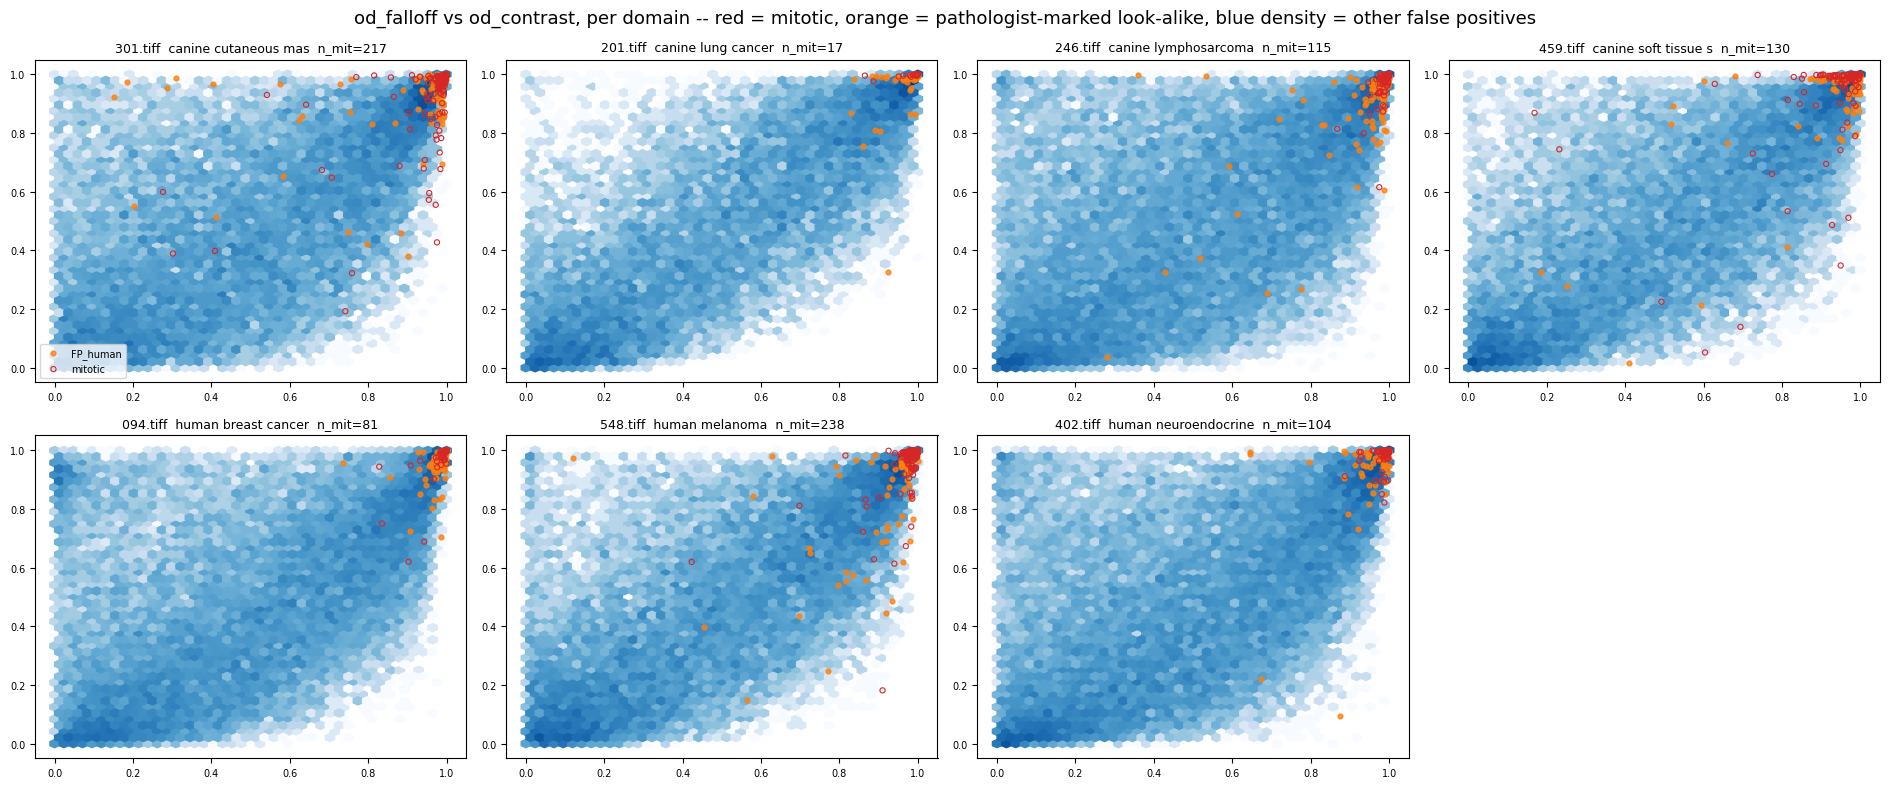

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, (fn, s) in zip(axes.ravel(), work.groupby('file_name', sort=False)):
    r_ = s[FEATURES].rank(pct=True)
    m = (s.klass2 == 'mitotic').to_numpy()
    h = (s.klass3 == 'FP_human').to_numpy()
    ax.hexbin(r_[fa][~m & ~h], r_[fb][~m & ~h], gridsize=42, cmap='Blues',
              norm=LogNorm(), mincnt=1)
    ax.scatter(r_[fa][h], r_[fb][h], s=12, color='tab:orange', alpha=0.8, label='FP_human')
    ax.scatter(r_[fa][m], r_[fb][m], s=14, facecolor='none', edgecolor='tab:red', lw=0.8,
               label='mitotic')
    ax.set_title(f'{fn}  {s.tumor_type.iloc[0][:20]}  n_mit={int(m.sum())}', fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=7, loc='lower left')
axes.ravel()[-1].axis('off')
fig.suptitle(f'{fa} vs {fb}, per domain -- red = mitotic, orange = pathologist-marked look-alike, '
             'blue density = other false positives', fontsize=13)
fig.tight_layout(); plt.show()

## 8. Clustering at k = 2 and k = 3, scored against the labels we already have

The class count is known, so k is fixed to it rather than swept. The output that matters is not the
scatter — it is the **contingency table against the true labels**, plus:

* **purity** of the mitotic-richest cluster, and its **enrichment** over the base rate;
* **adjusted Rand index** between the partition and the true labels (0 = chance, 1 = identical).
  Expect this to be near zero and **do not read it as "the clustering failed"** — ARI compares two
  partitions as partitions, and one side here has a 0.57% class against clusters holding tens of
  thousands of points. It can only be large if a cluster is *both* mitosis-pure and mitosis-sized.
  The statistic that matches the product question is capture-versus-cost: what share of mitoses a
  cluster holds, against what share of the pool it makes you read;
* **a permutation null** — labels shuffled *within ROI* so each ROI's base rate is preserved, 500
  draws. Enrichment of a best-of-k cluster has a non-zero null, and without the band a 1.5x lift
  reads as a finding.

k-means is used because it is the method most favourable to the hypothesis: if the mitotic figures
occupy a compact corner of this space, a 2-means split finds it. A Gaussian mixture is run beside
it because it can carve an elongated cluster k-means cannot.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture

X = rk.to_numpy(float)
y2 = (work.klass2 == 'mitotic').to_numpy().astype(int)
roi = work.file_name.to_numpy()
BASE = y2.mean()
N_PERM = 500


def enrich_of_best(labels, yv, min_n=50):
    n = np.bincount(labels)
    t = np.bincount(labels, weights=yv)
    rate = np.where(n >= min_n, t / np.maximum(n, 1), 0.0)
    e = rate / yv.mean()
    return float(e.max()), int(np.argmax(e))


def perm_null(labels, yv, roi_v, n_perm=N_PERM, seed=0):
    g = np.random.default_rng(seed)
    groups = [np.flatnonzero(roi_v == r) for r in np.unique(roi_v)]
    out = np.empty(n_perm)
    yp = yv.copy()
    for i in range(n_perm):
        for ix in groups:
            yp[ix] = g.permutation(yv[ix])
        out[i] = enrich_of_best(labels, yp)[0]
    return out


fits = {}
rows = []
for k in (2, 3):
    for name, mdl in [('k-means', KMeans(n_clusters=k, n_init=10, random_state=0)),
                      ('GMM', GaussianMixture(n_components=k, covariance_type='full',
                                              random_state=0, max_iter=200))]:
        lab = mdl.fit_predict(X)
        fits[(k, name)] = lab
        obs, which = enrich_of_best(lab, y2)
        null = perm_null(lab, y2, roi, seed=k * 7 + len(name))
        n_c = int((lab == which).sum()); tp_c = int(y2[lab == which].sum())
        rows.append({'k': k, 'method': name, 'best cluster n': n_c, 'mitotic in it': tp_c,
                     'purity': f'{tp_c / n_c:.3%}', 'enrichment': round(obs, 2),
                     'null p95': round(float(np.percentile(null, 95)), 2),
                     'beats null': obs > np.percentile(null, 95),
                     '% of mitoses captured': f'{tp_c / y2.sum():.1%}',
                     '% of pool it is': f'{n_c / len(y2):.1%}',
                     'ARI vs 2-class': round(adjusted_rand_score(y2, lab), 4)})
clus = pd.DataFrame(rows)
print(f'pooled, per-ROI-ranked features, base rate {BASE:.3%}\n')
print(clus.to_string(index=False))

pooled, per-ROI-ranked features, base rate 0.566%

 k  method  best cluster n  mitotic in it purity  enrichment  null p95  beats null % of mitoses captured % of pool it is  ARI vs 2-class
 2 k-means           74544            893 1.198%        2.12      1.06        True                 99.0%           46.8%          0.0017
 2     GMM           74654            890 1.192%        2.11      1.07        True                 98.7%           46.8%          0.0016
 3 k-means           57080            887 1.554%        2.75      1.13        True                 98.3%           35.8%         -0.0004
 3     GMM           22765            585 2.570%        4.54      1.16        True                 64.9%           14.3%          0.0082


In [20]:
for k in (2, 3):
    lab = fits[(k, 'k-means')]
    ct = pd.crosstab(pd.Series(lab, name=f'k-means cluster (k={k})'),
                     work.klass3.rename('true class'))
    ct_pct = (100 * ct.div(ct.sum(axis=0), axis=1)).round(1)
    print(f'--- k = {k}: how each true class is distributed over the clusters (column %) ---')
    print(ct_pct.to_string())
    print(f'\n    mitotic rate within each cluster (base rate {BASE:.3%}):')
    print(('      ' + (100 * ct['mitotic'] / ct.sum(axis=1)).round(3).astype(str) + ' %')
          .to_string())
    print()

--- k = 2: how each true class is distributed over the clusters (column %) ---
true class               FP  FP_human  mitotic
k-means cluster (k=2)                         
0                      53.7       1.8      1.0
1                      46.3      98.2     99.0

    mitotic rate within each cluster (base rate 0.566%):
k-means cluster (k=2)
0          0.011 %
1          1.198 %

--- k = 3: how each true class is distributed over the clusters (column %) ---
true class               FP  FP_human  mitotic
k-means cluster (k=3)                         
0                      25.6       1.9      1.1
1                      39.2       0.9      0.6
2                      35.2      97.2     98.3

    mitotic rate within each cluster (base rate 0.566%):


k-means cluster (k=3)
0          0.025 %
1          0.008 %
2          1.554 %



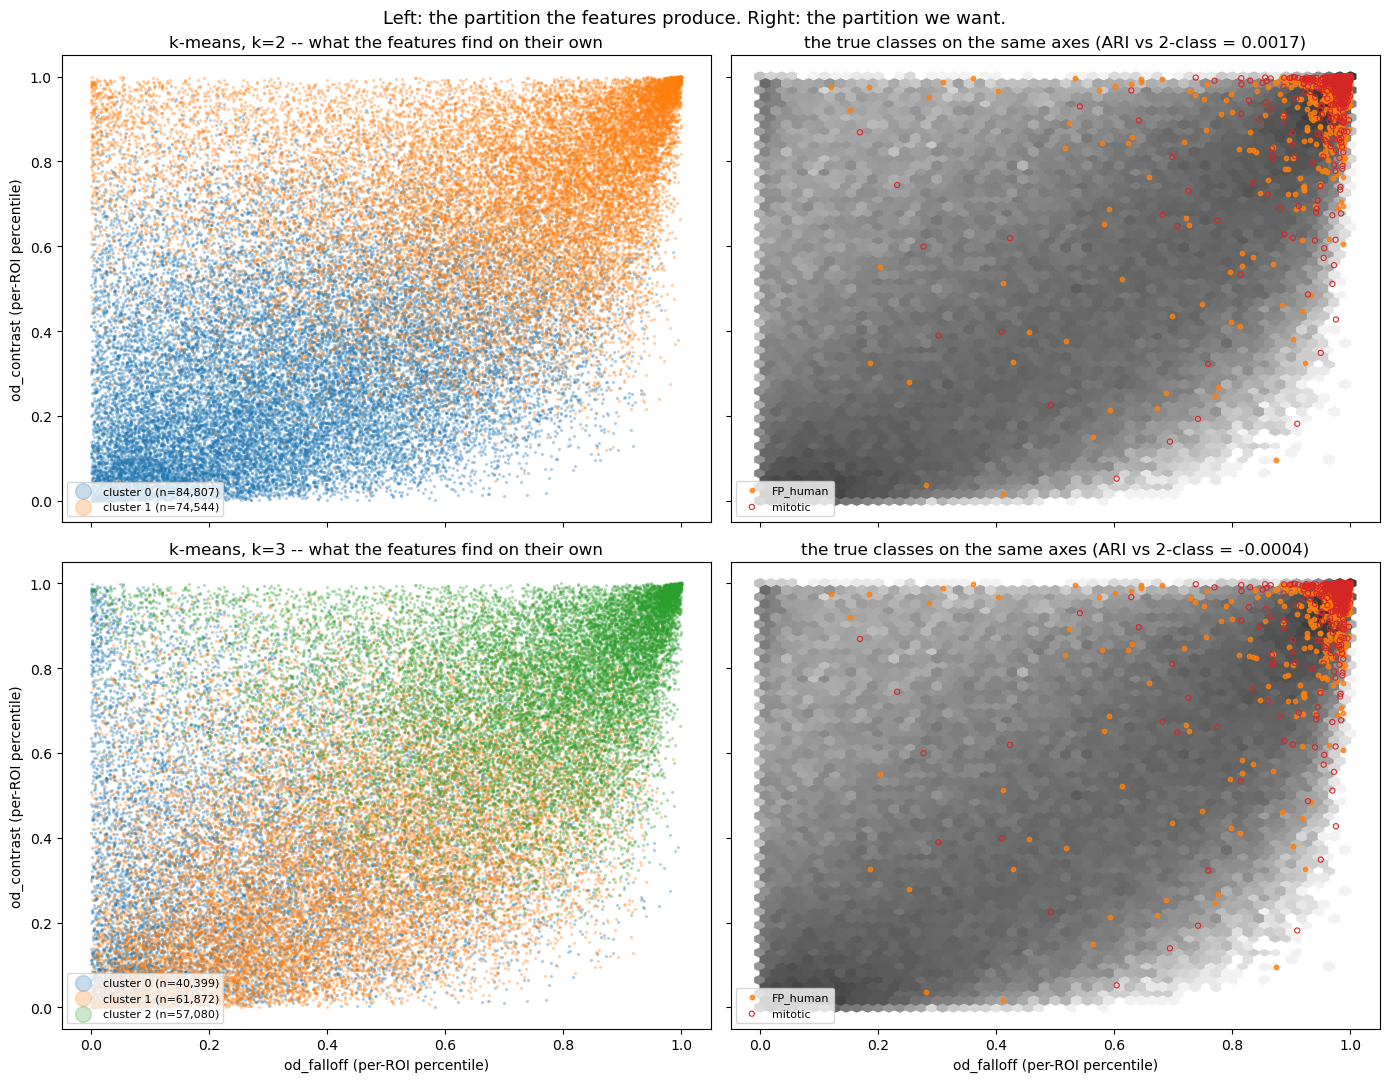

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
sub = np.random.default_rng(1).choice(len(work), size=45000, replace=False)
for row, k in enumerate((2, 3)):
    lab = fits[(k, 'k-means')]
    ax = axes[row, 0]
    for c in range(k):
        m = (lab[sub] == c)
        ax.scatter(xa[sub][m], xb[sub][m], s=2, alpha=0.25, label=f'cluster {c} (n={int((lab==c).sum()):,})')
    ax.legend(markerscale=8, fontsize=8, loc='lower left')
    ax.set_title(f'k-means, k={k} -- what the features find on their own')
    ax = axes[row, 1]
    ax.hexbin(xa[~mit & ~(work.klass3 == "FP_human").to_numpy()],
              xb[~mit & ~(work.klass3 == "FP_human").to_numpy()],
              gridsize=55, cmap='Greys', norm=LogNorm(), mincnt=1)
    ax.scatter(xa[(work.klass3 == 'FP_human').to_numpy()],
               xb[(work.klass3 == 'FP_human').to_numpy()], s=10, color='tab:orange',
               alpha=0.8, label='FP_human')
    ax.scatter(xa[mit], xb[mit], s=14, facecolor='none', edgecolor='tab:red', lw=0.8,
               label='mitotic')
    ax.legend(fontsize=8, loc='lower left')
    ax.set_title(f'the true classes on the same axes (ARI vs 2-class = '
                 f'{adjusted_rand_score(y2, lab):.4f})')
for ax in axes[1]:
    ax.set_xlabel(f'{fa} (per-ROI percentile)')
for ax in axes[:, 0]:
    ax.set_ylabel(f'{fb} (per-ROI percentile)')
fig.suptitle('Left: the partition the features produce. Right: the partition we want.', fontsize=13)
fig.tight_layout(); plt.show()

In [22]:
# per-ROI, so a pooled null cannot hide a domain where it does work
rows = []
for fn, s in work.groupby('file_name', sort=False):
    Xr = s[FEATURES].rank(pct=True).to_numpy(float)
    yv = (s.klass2 == 'mitotic').to_numpy().astype(int)
    r = {'file': fn, 'domain': s.tumor_type.iloc[0][:22], 'mitotic': int(yv.sum()),
         'base rate': f'{yv.mean():.2%}'}
    for k in (2, 3):
        lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xr)
        obs, _ = enrich_of_best(lab, yv)
        nul = perm_null(lab, yv, np.zeros(len(yv)), n_perm=300, seed=k)
        r[f'k={k} enrich'] = round(obs, 2)
        r[f'k={k} null p95'] = round(float(np.percentile(nul, 95)), 2)
        r[f'k={k} beats null'] = obs > np.percentile(nul, 95)
        r[f'k={k} ARI'] = round(adjusted_rand_score(yv, lab), 4)
    rows.append(r)
print('per-ROI clustering (each ROI ranked and clustered on its own)\n')
print(pd.DataFrame(rows).to_string(index=False))

per-ROI clustering (each ROI ranked and clustered on its own)

    file                 domain  mitotic base rate  k=2 enrich  k=2 null p95  k=2 beats null  k=2 ARI  k=3 enrich  k=3 null p95  k=3 beats null  k=3 ARI
301.tiff canine cutaneous mast       217     0.99%        2.00          1.12            True   0.0013        2.99          1.20            True   0.0012
201.tiff     canine lung cancer       17     0.10%        1.88          1.44            True  -0.0002        2.92          1.84            True  -0.0001
246.tiff   canine lymphosarcoma      115     0.44%        2.20          1.19            True   0.0018        3.38          1.29            True   0.0013
459.tiff canine soft tissue sar      130     0.62%        1.94          1.18            True   0.0003        2.65          1.27            True  -0.0006
094.tiff    human breast cancer       81     0.31%        2.33          1.21            True   0.0021        3.84          1.36            True   0.0017
548.tiff         hu

## 9. The direct answer: knowing the labels, how far do these features get?

Clustering is label-free and therefore a lower bound. **Using** the labels is the question actually
asked, and the only non-circular way to answer it is to fit on some ROIs and score another.
Leave-one-domain-out: fit on six ROIs, score the seventh. One ROI per domain means there is no
sibling-ROI leak — unlike the `*_loro` arms in `results/fp_filter_domain.csv`, which train on the
other ROI of the same domain.

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

Xf = rk.to_numpy(float)
rows, held = [], {}
for fn in work.file_name.unique():
    te = (roi == fn); tr = ~te
    lr = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=3000, class_weight='balanced')).fit(Xf[tr], y2[tr])
    gb = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.08, max_leaf_nodes=15,
                                        l2_regularization=1.0, class_weight='balanced',
                                        random_state=0).fit(Xf[tr], y2[tr])
    s_gb = gb.predict_proba(Xf[te])[:, 1]
    held[fn] = (s_gb, y2[te])
    br = y2[te].mean()
    sub_ = work[te]
    rows.append({'file': fn, 'domain': sub_.tumor_type.iloc[0][:22], 'mitotic': int(y2[te].sum()),
                 'base rate': f'{br:.3%}',
                 'LR AUC': round(roc_auc_score(y2[te], lr.predict_proba(Xf[te])[:, 1]), 3),
                 'GB AUC': round(roc_auc_score(y2[te], s_gb), 3),
                 'GB AP lift': f'{average_precision_score(y2[te], s_gb) / br:.0f}x',
                 'od51 alone AUC': round(roc_auc_score(y2[te], sub_.od51), 3),
                 'od51 AP lift': f'{average_precision_score(y2[te], sub_.od51) / br:.0f}x',
                 'z alone AUC': round(roc_auc_score(y2[te], sub_.z), 3)})
lodo = pd.DataFrame(rows)
print('leave-one-DOMAIN-out: fit on six ROIs, score the seventh\n')
print(lodo.to_string(index=False))

leave-one-DOMAIN-out: fit on six ROIs, score the seventh

    file                 domain  mitotic base rate  LR AUC  GB AUC GB AP lift  od51 alone AUC od51 AP lift  z alone AUC
301.tiff canine cutaneous mast       217    0.985%   0.975   0.972        57x           0.933          46x        0.930
201.tiff     canine lung cancer       17    0.103%   0.992   0.994       264x           0.995         229x        0.994
246.tiff   canine lymphosarcoma      115    0.435%   0.988   0.994        99x           0.973         104x        0.983
459.tiff canine soft tissue sar      130    0.625%   0.944   0.955        55x           0.928          79x        0.922
094.tiff    human breast cancer       81    0.312%   0.983   0.989       151x           0.980         130x        0.983
548.tiff         human melanoma      238    1.155%   0.985   0.991        53x           0.968          48x        0.984
402.tiff human neuroendocrine t      104    0.384%   0.994   0.995       124x           0.975         

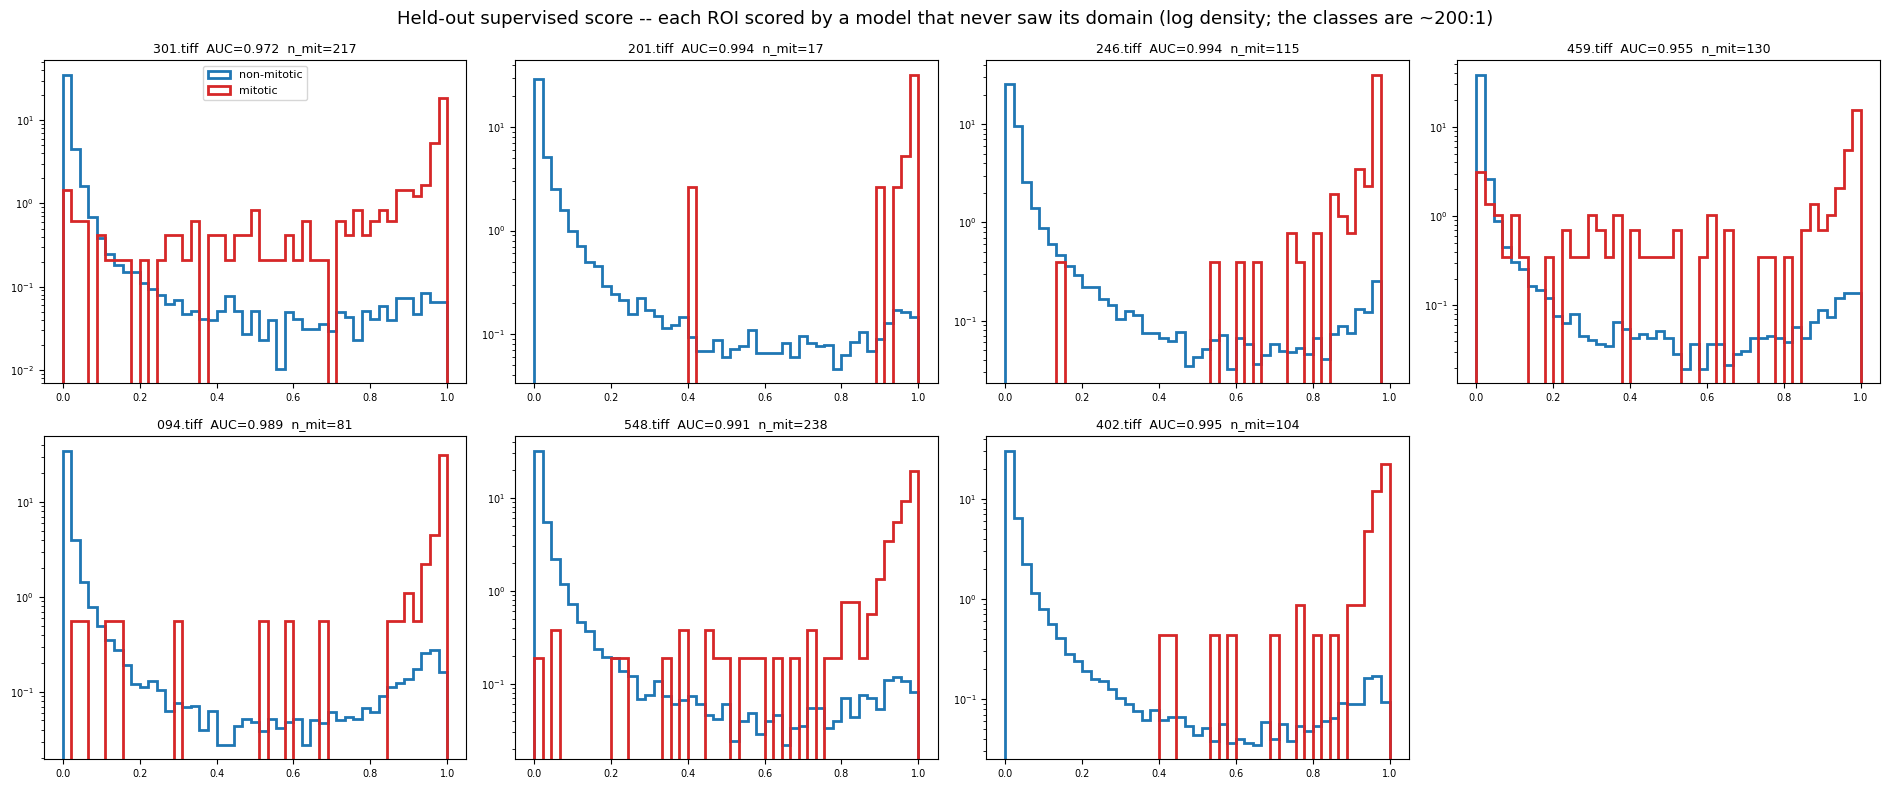

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, (fn, (s_, y_)) in zip(axes.ravel(), held.items()):
    bins = np.linspace(0, 1, 46)
    ax.hist(s_[y_ == 0], bins=bins, density=True, histtype='step', lw=2, color='tab:blue',
            label='non-mitotic')
    ax.hist(s_[y_ == 1], bins=bins, density=True, histtype='step', lw=2, color='tab:red',
            label='mitotic')
    ax.set_yscale('log')
    ax.set_title(f'{fn}  AUC={roc_auc_score(y_, s_):.3f}  n_mit={int(y_.sum())}', fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
axes.ravel()[-1].axis('off')
fig.suptitle('Held-out supervised score -- each ROI scored by a model that never saw its domain '
             '(log density; the classes are ~200:1)', fontsize=13)
fig.tight_layout(); plt.show()

In [25]:
def depth(scores, yv, qs=(0.5, 0.9, 0.95, 1.0)):
    o = np.argsort(-np.asarray(scores), kind='mergesort')
    hits = np.flatnonzero(np.asarray(yv)[o] == 1)
    return {q: (int(hits[int(np.ceil(q * len(hits))) - 1]) + 1 if len(hits) else np.nan)
            for q in qs}


rows = []
for fn in work.file_name.unique():
    te = (roi == fn); s = work[te]; yv = y2[te]
    for name, sc in [('z (search score)', s.z.to_numpy()),
                     ('od51 (chromatin)', s.od51.to_numpy()),
                     ('supervised, LODO', held[fn][0])]:
        d = depth(sc, yv)
        rows.append({'file': fn, 'n_cand': int(te.sum()), 'mitotic': int(yv.sum()), 'ranker': name,
                     **{f'read_{int(q * 100)}': d[q] for q in (0.5, 0.9, 0.95, 1.0)}})
tails = pd.DataFrame(rows)
print('candidates a reader must work through to reach each sensitivity level\n')
print(tails.set_index(['file', 'ranker']).to_string())

piv = tails.pivot_table(index='file', columns='ranker', values='read_95')
piv['supervised / od51'] = (piv['supervised, LODO'] / piv['od51 (chromatin)']).round(2)
piv['supervised / z'] = (piv['supervised, LODO'] / piv['z (search score)']).round(2)
print('\nread_95 ratios (below 1.0 = the supervised model gives a shorter list)\n')
print(piv.to_string())

candidates a reader must work through to reach each sensitivity level

                           n_cand  mitotic  read_50  read_90  read_95  read_100
file     ranker                                                                
301.tiff z (search score)   22029      217      345     4651     9345     15787
         od51 (chromatin)   22029      217      191     5014     9585     17019
         supervised, LODO   22029      217      155      946     2751     18798
201.tiff z (search score)   16513       17       42      274      664       664
         od51 (chromatin)   16513       17       26      159      792       792
         supervised, LODO   16513       17       32      260      877       877
246.tiff z (search score)   26411      115      132     1451     1877      6183
         od51 (chromatin)   26411      115      141     1943     3391     16432
         supervised, LODO   26411      115      101      524      675      2379
459.tiff z (search score)   20801      130      4

## 10. The answer

**Yes — these features separate mitotic figures from the search's own false positives, and by a
wide margin. And it does not shorten the list nearly as much as that sounds.**

Both halves of that sentence are in the tables above, and holding them together is the whole point.

**1. On the bulk, separation is close to complete.** Every chromatin feature reads AUC 0.92–0.997
against the unannotated false positives, **in all seven domains**, with average-precision lifts of
37x to 277x over base rates of 0.10–1.15%. `od_falloff` (`od31 − od81`, how sharply the dense core
falls off) is the strongest at 0.939–0.993, marginally ahead of `od_contrast` and `od51`.

**2. This is far better than the negatives were predicted to be, and the reason matters.**
`morphometric_diagnostic_audit.ipynb` §7 measured chromatin at AUC 0.655–0.976 against the darkest
10% of nuclei. Against the matcher's own candidates it reads 0.928–0.996 — *easier*, not harder.
The implication is that **`TM_CCOEFF` at `z >= 1.0` is not selecting dark nuclei.** Most of what it
admits is not a hard mimicker; it is a window a chromatin statistic dismisses immediately. (The two
measurements use different channels, so read this as a strong hint rather than a matched
comparison.)

**3. High AUC and a long list are not in conflict — this is what 0.5% prevalence does.** `od51` on
`301.tiff` separates at AUC 0.933 and still needs **9,585 of 22,029 candidates to reach 95%
sensitivity**. The audit made this point with a hypothetical; here it is measured end to end on the
real pool. An AUC is a statement about the median positive; the reader lives in the tail.

**4. Against the look-alikes, separation collapses.** The same chromatin features drop to AUC
0.62–0.80, and every shape feature lands between 0.43 and 0.72 with no consistent sign. This
confirms `morphometric_diagnostic_audit.ipynb` §8 from a second direction and on a different
candidate population: **whatever distinguishes a mitosis from a pathologist-marked mimicker is not
in this feature set.** They are only 670 of 159,351 candidates, so they are not the volume problem
— but they are the part no feature here touches.

**5. Shape is real and weak, exactly as the audit predicted.** `solidity` 0.71–0.93 and `extent`
0.66–0.86 are genuine, and `tightened_size` at 0.075–0.306 says mitoses are *smaller* (0.69–0.93
in the other direction) in all seven domains — the audit's finding, reproduced on a completely
different negative population. But their AP lifts are 2–10x against chromatin's 37–277x. They
separate; they do not rank.

**6. Clustering at k = 2 works — as a rejection filter, not as a mitosis finder.** A 2-means split
on these eight features puts **99.0% of the mitoses in one cluster holding 46.8% of the pool**.
Discarding the other cluster throws away 53.7% of the false positives and loses 1.0% of the
mitoses, with no labels used at all. It beats its within-ROI permutation null in **all seven ROIs
individually**. At k = 3, a GMM concentrates 64.9% of mitoses into 14.3% of the pool (4.5x
enrichment). What no partition does is isolate the mitoses: the best cluster is still 98.8%
false positives, which is why the ARI sits at ~0.002.

**7. With the labels, leave-one-domain-out reaches AUC 0.955–0.995 — and this one moves the
reader's list.** Against `od51`, the supervised score cuts `read_95` to **0.13x on 402.tiff, 0.18x
on 548.tiff, 0.20x on 246.tiff and 0.29x on 301.tiff** — a 3–8x shorter list at 95% sensitivity, on
domains the model never trained on. It is shorter on 5 of 7 ROIs. `read_100` stays brutal
(1,143–18,798), consistent with the convex tail this repo has measured repeatedly.

**The short version.** The features separate the classes. Almost all of that separation is
chromatin, not shape; it is spent on the easy 95% of the false positives, not the tail; it does
nothing for the pathologist-marked mimickers; and the one place it buys something decision-relevant
is a supervised leave-one-domain-out re-rank, which cuts the 95%-sensitivity reading depth by 3–8x
on four of seven domains.

In [26]:
uncens_med = (auc2[uncens] - 0.5).abs().median().sort_values(ascending=False)
top = uncens_med.index[0]
answer = {
    'negative class': 'the TM_CCOEFF + NMS candidate pool at z >= 1.0, not a uniform nucleus sample',
    'candidates / mitotic (pooled)': f'{len(work):,} / {int(y2.sum())}',
    'base rate per ROI': f'{work.groupby("file_name").klass2.apply(lambda s: (s == "mitotic").mean()).min():.2%}'
                         f' to {work.groupby("file_name").klass2.apply(lambda s: (s == "mitotic").mean()).max():.2%}',
    'set aside: FPs sitting on a real mitosis': f'{int(op.on_annotation.sum())} '
                                                 f'({op.on_annotation.sum() / y2.sum():.1f} per mitotic figure)',
    f'best single feature ({top}), AUC vs FP': f'{aucFP[top].min():.3f} to {aucFP[top].max():.3f}',
    f'best single feature ({top}), AUC vs FP_human': f'{aucH[top].min():.3f} to {aucH[top].max():.3f}',
    'od51 (the pipeline key), AUC vs all non-mitotic': f'{auc2.od51.min():.3f} to {auc2.od51.max():.3f}',
    'supervised LODO AUC (ceiling WITH labels)': f'{lodo["GB AUC"].min():.3f} to {lodo["GB AUC"].max():.3f}',
    'supervised LODO AP lift over base rate': f'{min(int(x[:-1]) for x in lodo["GB AP lift"])}x to '
                                              f'{max(int(x[:-1]) for x in lodo["GB AP lift"])}x',
    'k=2 clustering: enrichment / null p95 / ARI':
        f'{clus[(clus.k == 2) & (clus.method == "k-means")].enrichment.iloc[0]:.2f}x / '
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["null p95"].iloc[0]:.2f}x / '
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["ARI vs 2-class"].iloc[0]:.4f}',
    'k=3 clustering: enrichment / null p95 / ARI':
        f'{clus[(clus.k == 3) & (clus.method == "k-means")].enrichment.iloc[0]:.2f}x / '
        f'{clus[(clus.k == 3) & (clus.method == "k-means")]["null p95"].iloc[0]:.2f}x / '
        f'{clus[(clus.k == 3) & (clus.method == "k-means")]["ARI vs 2-class"].iloc[0]:.4f}',
    'read_95, supervised vs od51': f'{piv["supervised / od51"].min():.2f}x to '
                                   f'{piv["supervised / od51"].max():.2f}x '
                                   f'({int((piv["supervised / od51"] < 1).sum())} of {len(piv)} ROIs shorter)',
}
out = pd.DataFrame(answer.items(), columns=['quantity', 'value'])
pd.set_option('display.max_colwidth', 95)
print(out.to_string(index=False))

out.to_csv('results/tp_fp_separability_summary.csv', index=False)
auc2.to_csv('results/tp_fp_auc_2class.csv', index=False)
aucFP.to_csv('results/tp_fp_auc_vs_fp.csv', index=False)
aucH.to_csv('results/tp_fp_auc_vs_fp_human.csv', index=False)
clus.to_csv('results/tp_fp_cluster_k2_k3.csv', index=False)
lodo.to_csv('results/tp_fp_lodo_supervised.csv', index=False)
tails.to_csv('results/tp_fp_reading_depth.csv', index=False)
print('\nwrote 7 tables to results/')

                                         quantity                                                                        value
                                   negative class the TM_CCOEFF + NMS candidate pool at z >= 1.0, not a uniform nucleus sample
                    candidates / mitotic (pooled)                                                                159,351 / 902
                                base rate per ROI                                                               0.10% to 1.15%
         set aside: FPs sitting on a real mitosis                                                1211 (1.3 per mitotic figure)
      best single feature (od_falloff), AUC vs FP                                                               0.939 to 0.993
best single feature (od_falloff), AUC vs FP_human                                                               0.441 to 0.760
  od51 (the pipeline key), AUC vs all non-mitotic                                                              

## 11. Limitations

- **One seed per ROI.** `f1_seed_sweep.py` records that seed 0 sits on a seed-distribution endpoint
  for 3 of 7 ROIs. Pool *composition* is seed-dependent. Per-candidate feature distributions should
  not be at `coverage_frac` ≈ 0.95–1.00, but that is asserted here, not measured.
- **Shape is "the largest dark component in the 51 px window", not "the object under the click."**
  The segmentation is deliberately gate-free — `morphometric_diagnostic_audit.ipynb` §11 showed the
  usual `min_area`/`max_area_frac`/`min_solidity` gates truncate the very features being compared,
  and drop 9–12% of detections non-randomly. The price is that for a candidate not sitting on a
  nucleus, the measured component may belong to a neighbouring object.
- **`z` is censored by construction.** The pool is *defined* by `z >= 1.0`, so its distribution is
  truncated at the operating point and its AUC understates what the score does over its full range.
  It is excluded from every "best feature" selection for that reason, and kept in the tables.
- **Per-ROI ranking removes between-ROI signal** (§5). `od_contrast` and `od_falloff` are
  within-image differences and the per-ROI tables need no normalisation, so both are reported.
- **The largest-CC arm is a known-slightly-worse ranker.** `Research Logs/2026-09-04-f1-results.md`
  found tightening hurts ranking dose-dependently below ~36 px. It is the arm that was asked for,
  and it is a *ranking* finding rather than a feature-structure one, but anything load-bearing
  should be re-checked on `base51`.
- **`201.tiff` has 17 mitotic figures.** Its rows are reported for completeness and carry no weight.